## Imports + Run models

In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import joblib
import os

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFECV, SequentialFeatureSelector
from sklearn.model_selection import KFold

from sklearn.base import clone
import joblib
import shap
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

import seaborn as sns


pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.15f' % x)  # Exibe 5 casas decimais


In [3]:
shapefile_path = '../../dataset/shp/clusters.shp'
X_vars = [
    'age_index', 'median_age', 'sex_ratio', 'literate',
    'race_wht', 'race_blk', 'race_ylw', 'race_brn', 'race_ind', 'race_unk',
    'depriv_idx', 'wtr_area', 'veg_area', 'risk_area',
    'slope_10', 'slope_20', 'slope_30', 'slope_30p',
    'hand_6p', 'hand_3_6', 'hand_0_3',
    'SO2', 'CO', 'O3', 'NO2',
    'waste_coll', 'est_dens', 'est_edu', 'est_health',
    'est_relig', 'est_agri', 'est_other', 'est_const', 'intra_veg',
    'prim_hosp', 'inp_hosp'
]
Y_vars = ['wtr_idx', 'sanit_idx']

os.makedirs("../../dataset/models", exist_ok=True)

gdf = gpd.read_file(shapefile_path)
gdf = gdf.dropna()
# set population log
# gdf['population'] = np.log(gdf['population'])
X = gdf[X_vars]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
def evaluate_model(model, X_eval, y):
    """Calcula R², RMSE e retorna métricas"""
    y_pred = model.predict(X_eval)
    r2 = r2_score(y, y_pred)
    rmse = mean_squared_error(y, y_pred)
    return r2, rmse

def save_model(model, name):
    joblib.dump(model, f"../../dataset/models/{name}.pkl")

def run_lasso(X_scaled, y, X_vars):
    model = LassoCV(cv=5, random_state=42)
    model.fit(X_scaled, y)
    selected = {var: coef for var, coef in zip(X_vars, model.coef_) if coef != 0}
    return model, selected

def run_rfecv(model, X, y, X_vars):
    rfecv = RFECV(
        estimator=model,
        step=1,
        cv=KFold(5, shuffle=True, random_state=42),
        scoring='r2',
        n_jobs=-1
    )
    rfecv.fit(X, y)

    # nomes selecionados (ordem preservada em X_vars)
    mask = rfecv.support_
    selected_vars = np.array(X_vars)[mask]

    # importâncias do estimador final (treinado só com as selecionadas)
    importances = rfecv.estimator_.feature_importances_

    # monta dict correto: soma deve ser ~1.0
    selected = dict(zip(selected_vars, importances))

    # print(f"Selecionadas: {rfecv.n_features_}/{X.shape[1]}")
    # print(pd.Series(selected).sort_values(ascending=False))

    return rfecv, selected

def run_sfs(model, X, y, X_vars, direction='forward',
            n_features_to_select='auto', tol=None, scoring='r2'):
    sfs = SequentialFeatureSelector(
        estimator=model,
        direction=direction,                    # 'forward' ou 'backward'
        n_features_to_select=n_features_to_select,  # 'auto' (metade) ou int/float
        tol=tol,                                # se usar 'auto', pode definir tol>0
        scoring=scoring,                        # 'r2' para regressão
        cv=KFold(5, shuffle=True, random_state=42),
        n_jobs=-1
    )
    sfs.fit(X, y)

    # 1) Máscara e nomes selecionados (ordem = a do X_vars)
    mask = sfs.get_support()
    selected_vars = np.array(X_vars)[mask]

    # 2) Re-treina o modelo APENAS com as features selecionadas
    X_sel = X.loc[:, selected_vars] if hasattr(X, "loc") else X[:, mask]
    est = clone(model).fit(X_sel, y)

    # 3) Extrai importâncias/coefs do modelo re-treinado
    if hasattr(est, "feature_importances_"):
        vals = est.feature_importances_
    elif hasattr(est, "coef_"):
        # para regressão linear, pegar módulo ajuda a comparar magnitude
        vals = np.abs(np.ravel(est.coef_))
    else:
        vals = [None] * len(selected_vars)

    selected = dict(zip(selected_vars, vals))
    return sfs, selected

In [6]:
results = []


In [ ]:

for idx in Y_vars:
    y = gdf[idx]
    print(f"\n=== Analisando índice: {idx} ===")
    
    # 1️⃣ LassoCV
    # lasso_model, lasso_features = run_lasso(X_scaled, y, X_vars)
    # r2, rmse = evaluate_model(lasso_model, pd.DataFrame(X_scaled, columns=X_vars), y)
    # save_model(lasso_model, f"multi_{idx}_lasso")
    # results.append([idx, 'LassoCV', r2, rmse, len(lasso_features), lasso_features])
    
    # 2️⃣ RFECV RandomForest
    print("RandomForestRegressor - wtr_idx")
    rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    model, rf_features = run_rfecv(rf_model, X, y, X_vars)
    features = list(rf_features.keys())
    r2, rmse = evaluate_model(rf_model.fit(X[features], y), X[features], y)
    # save_model(rf_model, f"multi_{idx}_rfecv_rf")
    # results.append([idx, 'RFECV_RF', r2, rmse, len(features), rf_features])

    # 3️⃣ XGBRegressor
    # print("XGBRegressor - wtr_idx")
    # xgb_model = XGBRegressor(random_state=42)
    # model, xgb_features = run_rfecv(xgb_model, X, y, X_vars)
    # features = list(xgb_features.keys())
    # r2, rmse = evaluate_model(xgb_model.fit(X[features], y), X[features], y)
    # save_model(xgb_model, f"multi_{idx}_xgb")
    # results.append([idx, 'XGBRegressor', r2, rmse, len(features), xgb_features])
    
    # # 3️⃣ SFS RandomForest
    # print("SFS RandomForest")
    # rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    # model, sfs_rf_features = run_sfs(rf_model, X, y, X_vars)
    # features = list(sfs_rf_features.keys())
    # r2, rmse = evaluate_model(rf_model.fit(X[features], y), X[features], y)
    # save_model(rf_model, f"multi_{idx}_sfs_rf")
    # results.append([idx, 'SFS_RF', r2, rmse, len(sfs_rf_features), sfs_rf_features])

#     # break



=== Analisando índice: wtr_idx ===
RandomForestRegressor - wtr_idx


Exception ignored in: <function ResourceTracker.__del__ at 0x103b40e00>
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106a64e00>
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versi


=== Analisando índice: sanit_idx ===
RandomForestRegressor - wtr_idx


Exception ignored in: <function ResourceTracker.__del__ at 0x105064e00>
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1064fce00>
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versi

In [7]:
print("RandomForestRegressor - wtr_idx")
idx = 'wtr_idx'
y = gdf[idx]
x = pd.DataFrame(X_scaled, columns=X_vars)
rf_model_wtr = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
_, rf_features_wtr = run_rfecv(rf_model_wtr, x, y, X_vars)
features = list(rf_features_wtr.keys())
r2, rmse = evaluate_model(rf_model_wtr.fit(x[features], y), x[features], y)
save_model(rf_model_wtr, f"multi_{idx}_rfecv_rf")
results.append([idx, 'RFECV_RF', r2, rmse, len(features), rf_features_wtr])

RandomForestRegressor - wtr_idx


In [8]:
print("RandomForestRegressor - sanit_idx")
idx = 'sanit_idx'
y = gdf[idx]
x = pd.DataFrame(X_scaled, columns=X_vars)
rf_model_sanit = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
_, rf_features_sanit = run_rfecv(rf_model_sanit, x, y, X_vars)
features = list(rf_features_sanit.keys())
r2, rmse = evaluate_model(rf_model_sanit.fit(x[features], y), x[features], y)
save_model(rf_model_sanit, f"multi_{idx}_rfecv_rf")
results.append([idx, 'RFECV_RF', r2, rmse, len(features), rf_features_sanit])

RandomForestRegressor - sanit_idx


Exception ignored in: <function ResourceTracker.__del__ at 0x103864e00>
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x110064e00>
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versi

## Exploration

In [9]:
results_df = pd.DataFrame(results, columns=["Índice", "Modelo", "R²", "RMSE", "Qtd_Variáveis", "Variáveis_Selecionadas"])
pd.set_option('display.max_colwidth', None)
# results_df.to_csv("../../dataset/models/resumo_selecao_variaveis_new.csv", index=False)
print("\nResumo final:")
results_df


Resumo final:


,Índice,Modelo,R²,RMSE,Qtd_Variáveis,Variáveis_Selecionadas
0,wtr_idx,RFECV_RF,0.915660449529330,0.002308122037050,8,"{'age_index': 0.10253993960040125, 'depriv_idx': 0.10188412235324965, 'CO': 0.2570371392005534, 'O3': 0.1231467630212243, 'NO2': 0.10191322994448408, 'waste_coll': 0.1252208940808448, 'est_dens': 0.08345974820523973, 'prim_hosp': 0.10479816359400287}"
1,sanit_idx,RFECV_RF,0.927274158595850,0.003287558585727,20,"{'age_index': 0.07862888484814141, 'sex_ratio': 0.030215398144715504, 'literate': 0.03530445755785235, 'race_wht': 0.02605963881959638, 'race_blk': 0.02687565473055099, 'race_brn': 0.022217162339419855, 'depriv_idx': 0.2510871971119206, 'veg_area': 0.022435890475230785, 'slope_10': 0.03679581090250805, 'hand_6p': 0.04294209534243565, 'hand_3_6': 0.022292534998378823, 'hand_0_3': 0.0257830484981306, 'SO2': 0.02739819544760433, 'CO': 0.05380155728942344, 'O3': 0.044671373728894355, 'NO2': 0.0631342878012079, 'waste_coll': 0.04863819169424067, 'est_dens': 0.0664064348695194, 'prim_hosp': 0.03619940417828724, 'inp_hosp': 0.039112781221941416}"


In [10]:
# Calcular valores SHAP
explainer_wtr = shap.TreeExplainer(rf_model_wtr)
features = list(rf_features_wtr.keys())
shap_values_wtr = explainer_wtr.shap_values(x[features])
# np.save("../../dataset/models/shap_values_wtr.npy", shap_values_wtr)

Exception ignored in: <function ResourceTracker.__del__ at 0x1053bce00>
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107a64e00>
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versi

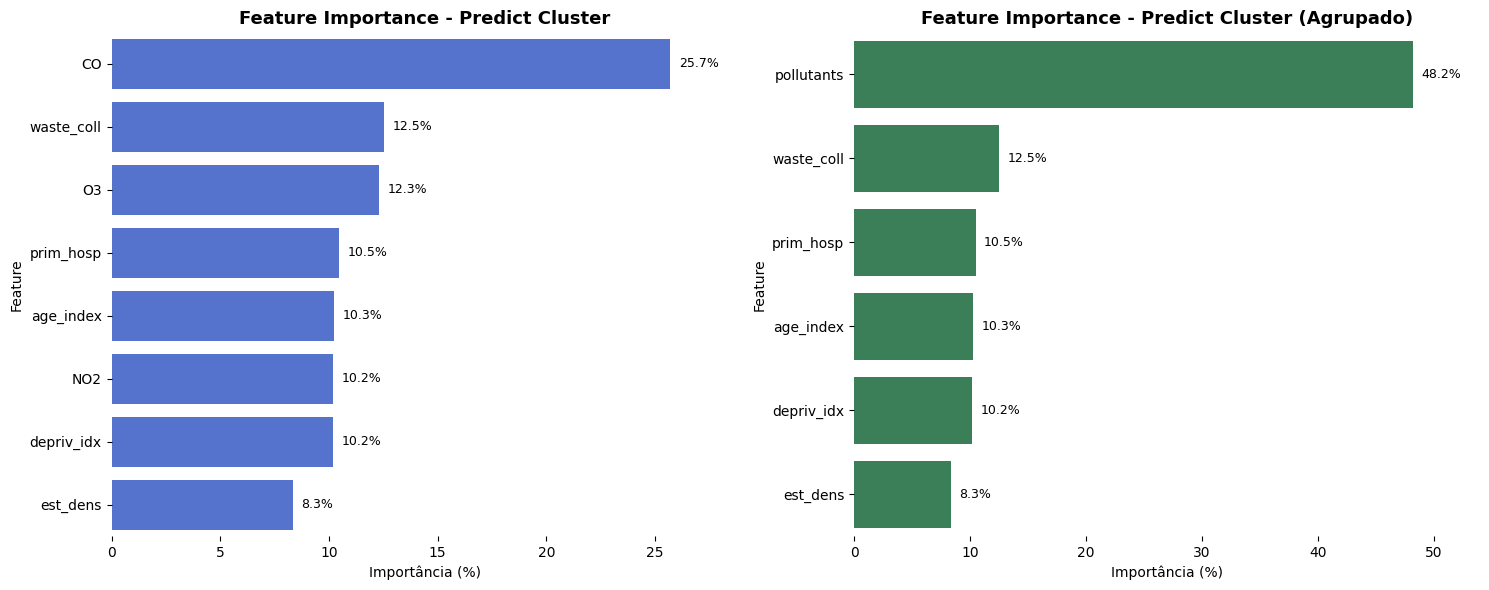

In [11]:
def dict_to_df(d, sort_desc=True):
    df = pd.DataFrame(list(d.items()), columns=["Feature", "Importance"])
    df["Importance_pct"] = df["Importance"] * 100
    df = df.sort_values("Importance_pct", ascending=not sort_desc).reset_index(drop=True)
    return df

def plot_hbar_with_labels(ax, df, title, color="royalblue"):
    sns.barplot(data=df, x="Importance_pct", y="Feature", color=color, ax=ax)
    for i, val in enumerate(df["Importance_pct"]):
        ax.text(val + df["Importance_pct"].max()*0.015, i, f"{val:.1f}%",
                va="center", fontsize=9)
    ax.set_xlabel("Importância (%)")
    ax.set_ylabel("Feature")
    ax.set_title(title, fontsize=13, weight="bold")
    ax.set_xlim(0, df["Importance_pct"].max() * 1.12)
    sns.despine(ax=ax, left=True, bottom=True)

def group_features(fi: dict):
    fi = fi.copy()
    pollutant_keys = ['CO', 'NO2', 'O3']

    pollutants_sum = sum(fi[k] for k in pollutant_keys)
    for k in pollutant_keys:
        fi.pop(k, None)

    fi['pollutants'] = pollutants_sum
    return fi

rf_imp = pd.Series(rf_model_wtr.feature_importances_, index=list(rf_features_wtr.keys()), name="RF_importance")
rf_imp_pct = 100 * rf_imp / rf_imp.sum()

# --- DataFrames ---
df_orig = dict_to_df(rf_imp, sort_desc=True)
# ensure rf_imp is a dict before passing
rf_imp_dict = dict(rf_imp) if not isinstance(rf_imp, dict) else rf_imp
df_group = dict_to_df(group_features(rf_imp_dict), sort_desc=True)

# --- plot lado a lado ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=False)
plot_hbar_with_labels(axes[0], df_orig, "Feature Importance - Predict Cluster", color="royalblue")
plot_hbar_with_labels(axes[1], df_group, "Feature Importance - Predict Cluster (Agrupado)", color="seagreen")
plt.tight_layout()
plt.show()

In [12]:
CLUSTER_COLORS = {
    0: "#3fa745",   # Structured
    1: "#fab800",   # Partially Structured
    2: "#dc3444"    # Unstructured
}
FEATURE_NAME_MAPPING = {
    'age_index':        'Age Index',
    'literate':         'Literate',
    'race_wht':         'White',
    'race_brn':         'Brown',
    'race_unk':         'Unknown Race',
    'median_age':       'Median Age',
    'depriv_idx':       'Deprivation Index',
    'slope_10':         'Slope >10%',
    'hand_0_3':         'HAND 0–3m',
    'hand_6p':          'HAND >6m',
    'SO2':              'Sulfur Dioxide (SO₂)',
    'CO':               'Carbon Monoxide (CO)',
    'O3':               'Ozone (O₃)',
    'NO2':              'Nitrogen Dioxide (NO₂)',
    'waste_coll':       'Waste Collection',
    'est_dens':         'Establishment Density',
    'wtr_area':         'Water Area',
    'risk_area':        'Risk Area',
    'prim_hosp':        'Primary Hospital',
    'inp_hosp':         'Inpatient Hospital',
    # Adicione outros nomes conforme necessário
}
def prettify_feature_names(cols):
    """Converte uma lista de nomes de variáveis para nomes legíveis."""
    return [FEATURE_NAME_MAPPING.get(col, col.replace('_', ' ').title()) for col in cols]

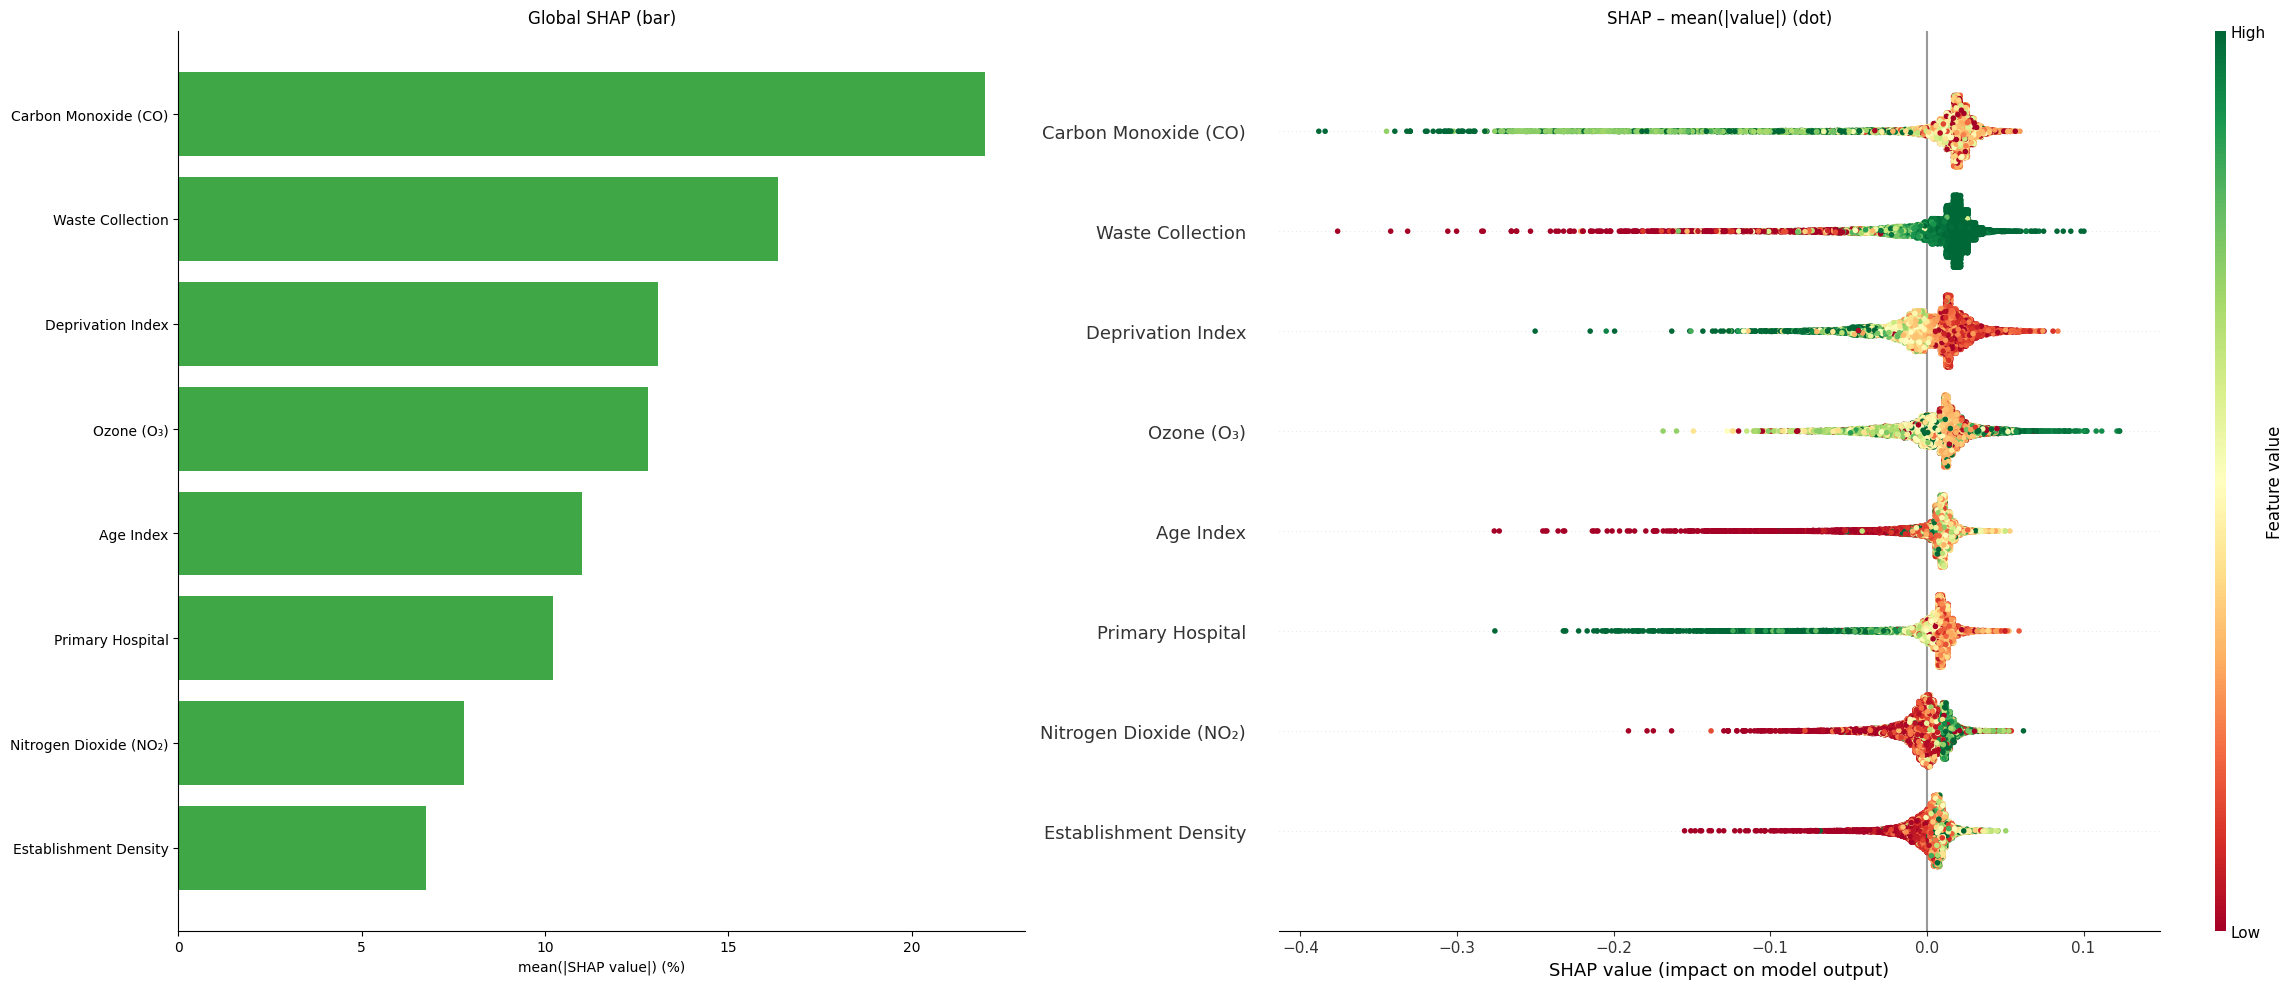

In [13]:
feat_list = list(rf_features_wtr.keys())
X_sel = x[feat_list]

shap_mean = np.abs(shap_values_wtr).mean(axis=0)
shap_pct = 100 * shap_mean / shap_mean.sum()
shap_pct_s = pd.Series(shap_pct, index=feat_list, name="SHAP_%")

# ----- ordenar pelas features mais importantes no SHAP -----
order = shap_pct_s.sort_values(ascending=False).index.tolist()
N = len(order)  # qtd de features
W = 14 + 0.25*N  # largura dinâmica
H = max(10, 0.45*N)

order_idx = [feat_list.index(f) for f in order]                 # índice das cols no shap_values_sanit
sv_ordered = shap_values_wtr[:, order_idx]
X_ordered  = X_sel[order]
rf_pct_ord = rf_imp_pct.loc[order]

# --- nomes bonitos para as features usando prettify_feature_names ---
pretty_feature_names = prettify_feature_names(order)

# ----- plot lado a lado -----
fig, axes = plt.subplots(1, 2, figsize=(N, W), gridspec_kw={'width_ratios':[1,1.3]})

# (esquerda) RF importances em % (matplotlib bar)
ax0 = axes[0]
sorted_global_shap_vals = shap_pct_s[order].values  # mesma ordem das features
bar_y_pos = np.arange(N)

ax0.barh(bar_y_pos, sorted_global_shap_vals, color=CLUSTER_COLORS[0])
ax0.set_yticks(bar_y_pos)
ax0.set_yticklabels(pretty_feature_names)
ax0.invert_yaxis()  # feature mais importante em cima
ax0.set_xlabel("mean(|SHAP value|) (%)")
ax0.set_title("Global SHAP (bar)")

# Remove apenas as bordas superior e direita
ax0.spines['top'].set_visible(False)
ax0.spines['right'].set_visible(False)
# Deixa as bordas inferior e esquerda visíveis (eixo x/y)
ax0.spines['left'].set_visible(True)
ax0.spines['bottom'].set_visible(True)

# (direita) SHAP summary (dot) na MESMA ordem
plt.sca(axes[1])
shap.summary_plot(
    sv_ordered,               # shap values reordenados
    X_ordered,                # DataFrame reordenado
    plot_type="dot",
    sort=False,               # respeita nossa ordem
    show=False,               # desenha no axes atual
    max_display=len(order),    # mostra todas
    cmap="RdYlGn",
    feature_names=pretty_feature_names  # mostra nomes bonitos no summary_plot
)
axes[1].set_title("SHAP – mean(|value|) (dot)", fontsize=12)
fig.set_size_inches(W*1.5, H)  # 50% mais larga
plt.tight_layout()
plt.show()


In [14]:
explainer_sanit = shap.TreeExplainer(rf_model_sanit)
features = list(rf_features_sanit.keys())
shap_values_sanit = explainer_sanit.shap_values(x[features])
# np.save("../../dataset/models/shap_values_sanit.npy", shap_values_sanit)

In [18]:
features

[np.str_('age_index'),
 np.str_('sex_ratio'),
 np.str_('literate'),
 np.str_('race_wht'),
 np.str_('race_blk'),
 np.str_('race_brn'),
 np.str_('depriv_idx'),
 np.str_('veg_area'),
 np.str_('slope_10'),
 np.str_('hand_6p'),
 np.str_('hand_3_6'),
 np.str_('hand_0_3'),
 np.str_('SO2'),
 np.str_('CO'),
 np.str_('O3'),
 np.str_('NO2'),
 np.str_('waste_coll'),
 np.str_('est_dens'),
 np.str_('prim_hosp'),
 np.str_('inp_hosp')]

In [17]:
def dict_to_df(d, sort_desc=True):
    df = pd.DataFrame(list(d.items()), columns=["Feature", "Importance"])
    df["Importance_pct"] = df["Importance"] * 100
    df = df.sort_values("Importance_pct", ascending=not sort_desc).reset_index(drop=True)
    return df

def plot_hbar_with_labels(ax, df, title, color="royalblue"):
    sns.barplot(data=df, x="Importance_pct", y="Feature", color=color, ax=ax)
    for i, val in enumerate(df["Importance_pct"]):
        ax.text(val + df["Importance_pct"].max()*0.015, i, f"{val:.1f}%",
                va="center", fontsize=9)
    ax.set_xlabel("Importância (%)")
    ax.set_ylabel("Feature")
    ax.set_title(title, fontsize=13, weight="bold")
    ax.set_xlim(0, df["Importance_pct"].max() * 1.12)
    sns.despine(ax=ax, left=True, bottom=True)

def group_features(fi: dict):
    fi = fi.copy()
    pollutant_keys = ['CO', 'NO2', 'O3', 'SO2']
    health_access_keys = ['prim_hosp', 'inp_hosp']
    topography_keys = ['slope_10', 'hand_0_3', 'hand_6p', 'hand_3_6']
    race_keys = ['race_wht', 'race_brn', 'race_blk']
    demographic_keys = ['age_index', 'literate', 'sex_ratio']

    pollutants_sum = sum(fi[k] for k in pollutant_keys)
    health_access_sum = sum(fi[k] for k in health_access_keys)
    topography_sum = sum(fi[k] for k in topography_keys)
    race_sum = sum(fi[k] for k in race_keys)
    demographic_sum = sum(fi[k] for k in demographic_keys)
    for k in pollutant_keys + health_access_keys + topography_keys + race_keys + demographic_keys:
        fi.pop(k, None)

    fi['pollutants'] = pollutants_sum
    fi['health_access'] = health_access_sum
    fi['topography'] = topography_sum
    fi['race'] = race_sum
    fi['demographic'] = demographic_sum
    return fi

# --- DataFrames ---
df_orig = dict_to_df(rf_imp, sort_desc=True)
# ensure rf_imp is a dict before passing
rf_imp_dict = dict(rf_imp) if not isinstance(rf_imp, dict) else rf_imp
df_group = dict_to_df(group_features(rf_imp_dict), sort_desc=True)

# --- plot lado a lado ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=False)
plot_hbar_with_labels(axes[0], df_orig, "Feature Importance - Predict Cluster", color="royalblue")
plot_hbar_with_labels(axes[1], df_group, "Feature Importance - Predict Cluster (Agrupado)", color="seagreen")
plt.tight_layout()
plt.show()

KeyError: 'SO2'

In [36]:
rf_imp_sanit = pd.Series(rf_model_sanit.feature_importances_, index=list(rf_features_sanit.keys()), name="RF_importance")
rf_imp_sanit_pct = 100 * rf_imp_sanit / rf_imp_sanit.sum()
rf_imp_sanit_pct

age_index     7.862888484814144
sex_ratio     3.021539814471551
literate      3.530445755785236
race_wht      2.605963881959639
race_blk      2.687565473055100
race_brn      2.221716233941986
depriv_idx   25.108719711192069
veg_area      2.243589047523079
slope_10      3.679581090250807
hand_6p       4.294209534243567
hand_3_6      2.229253499837883
hand_0_3      2.578304849813061
SO2           2.739819544760434
CO            5.380155728942346
O3            4.467137372889438
NO2           6.313428780120792
waste_coll    4.863819169424069
est_dens      6.640643486951942
prim_hosp     3.619940417828725
inp_hosp      3.911278122194143
Name: RF_importance, dtype: float64

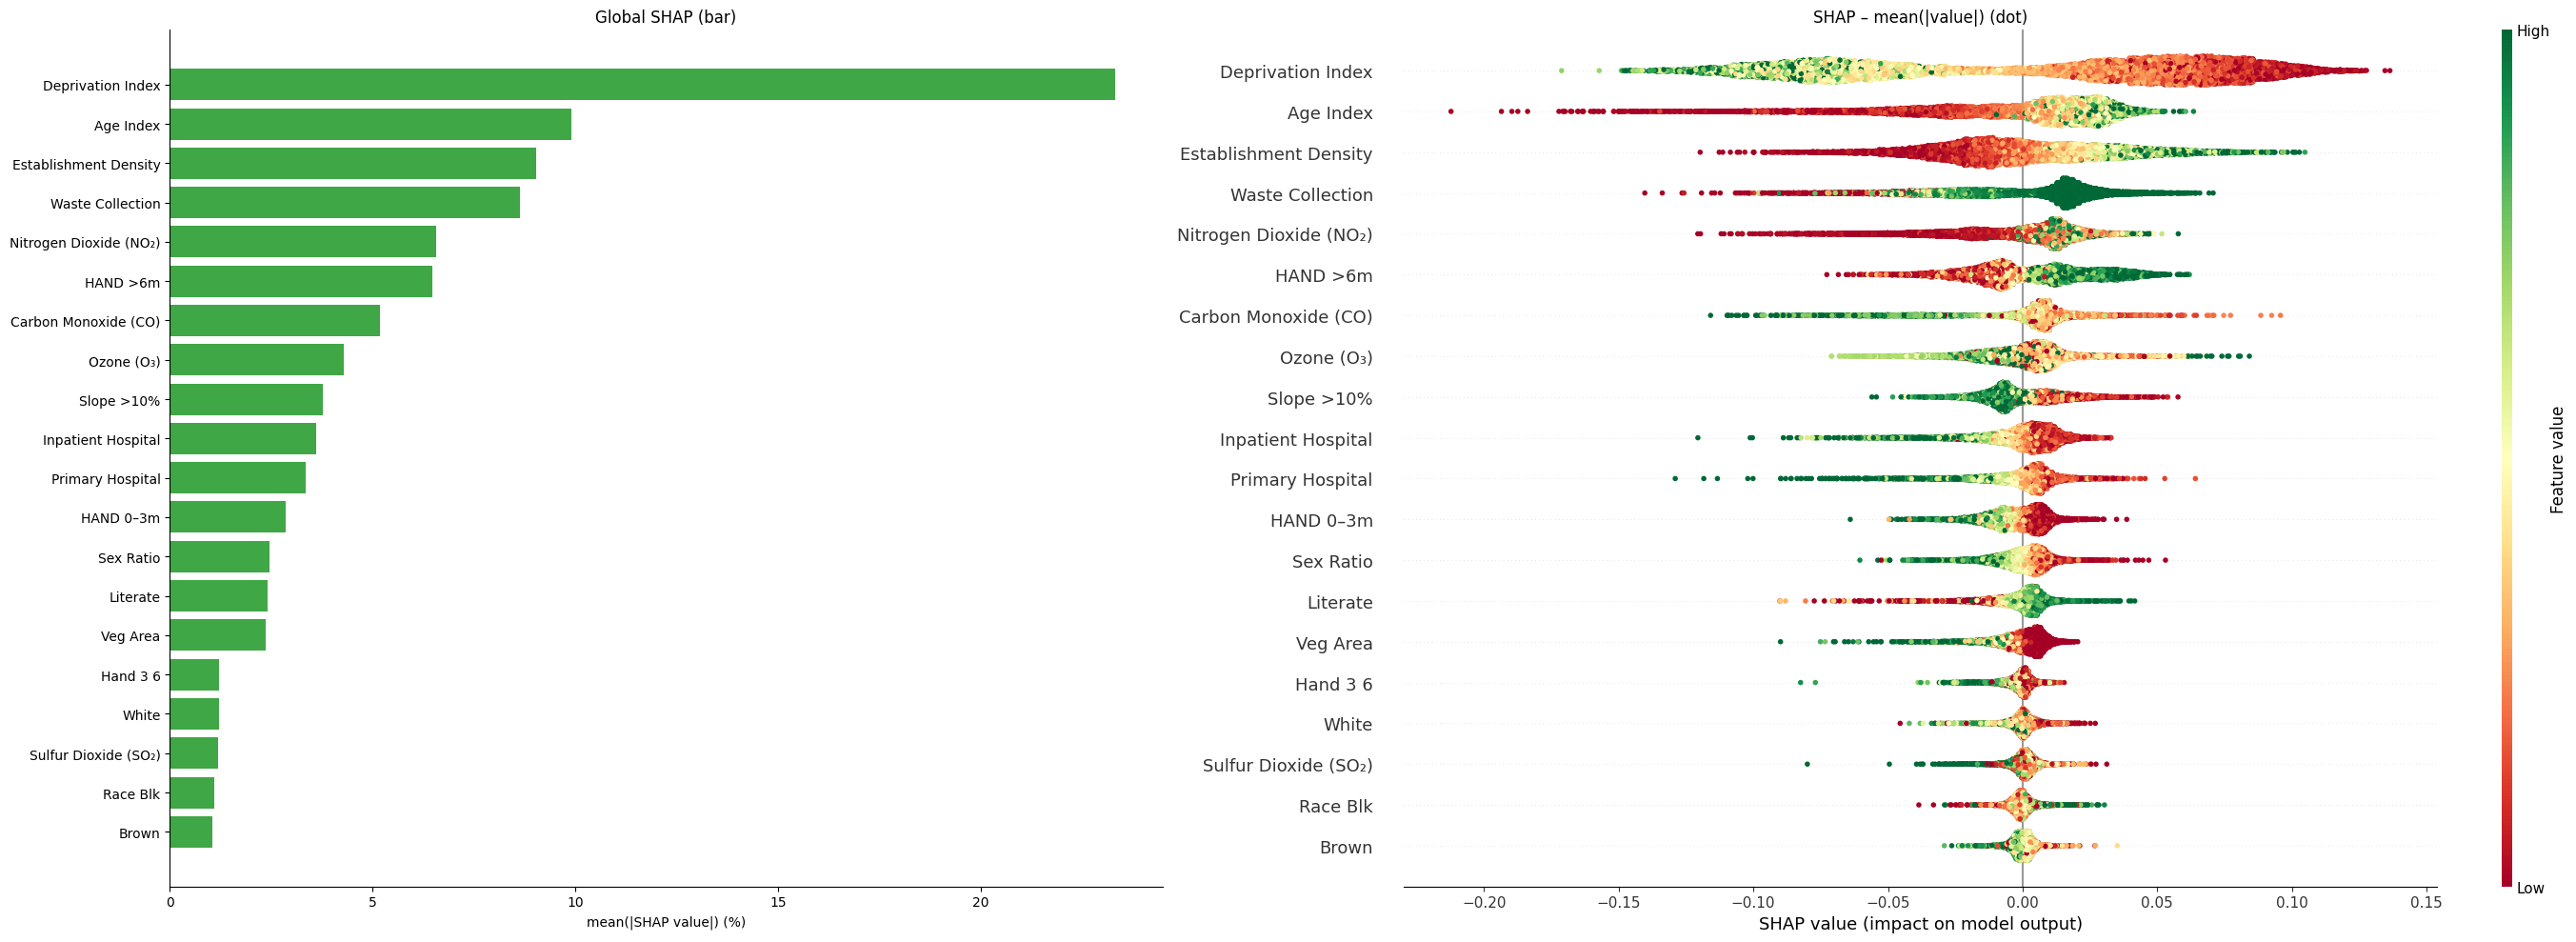

In [37]:
feat_list = list(rf_features_sanit.keys())
X_sel = x[feat_list]

shap_mean = np.abs(shap_values_sanit).mean(axis=0)
shap_pct = 100 * shap_mean / shap_mean.sum()
shap_pct_s = pd.Series(shap_pct, index=feat_list, name="SHAP_%")

# ----- ordenar pelas features mais importantes no SHAP -----
order = shap_pct_s.sort_values(ascending=False).index.tolist()
N = len(order)  # qtd de features
W = 14 + 0.25*N  # largura dinâmica
H = max(10, 0.45*N)

order_idx = [feat_list.index(f) for f in order]                 # índice das cols no shap_values_sanit
sv_ordered = shap_values_sanit[:, order_idx]
X_ordered  = X_sel[order]
rf_pct_ord = rf_imp_sanit_pct.loc[order]

# --- nomes bonitos para as features usando prettify_feature_names ---
pretty_feature_names = prettify_feature_names(order)

# ----- plot lado a lado -----
fig, axes = plt.subplots(1, 2, figsize=(N, W), gridspec_kw={'width_ratios':[1,1.3]})

# (esquerda) RF importances em % (matplotlib bar)
ax0 = axes[0]
sorted_global_shap_vals = shap_pct_s[order].values  # mesma ordem das features
bar_y_pos = np.arange(N)

ax0.barh(bar_y_pos, sorted_global_shap_vals, color=CLUSTER_COLORS[0])
ax0.set_yticks(bar_y_pos)
ax0.set_yticklabels(pretty_feature_names)
ax0.invert_yaxis()  # feature mais importante em cima
ax0.set_xlabel("mean(|SHAP value|) (%)")
ax0.set_title("Global SHAP (bar)")

# Remove apenas as bordas superior e direita
ax0.spines['top'].set_visible(False)
ax0.spines['right'].set_visible(False)
# Deixa as bordas inferior e esquerda visíveis (eixo x/y)
ax0.spines['left'].set_visible(True)
ax0.spines['bottom'].set_visible(True)

# (direita) SHAP summary (dot) na MESMA ordem
plt.sca(axes[1])
shap.summary_plot(
    sv_ordered,               # shap values reordenados
    X_ordered,                # DataFrame reordenado
    plot_type="dot",
    sort=False,               # respeita nossa ordem
    show=False,               # desenha no axes atual
    max_display=len(order),    # mostra todas
    cmap="RdYlGn",
    feature_names=pretty_feature_names  # mostra nomes bonitos no summary_plot
)
axes[1].set_title("SHAP – mean(|value|) (dot)", fontsize=12)
fig.set_size_inches(W*1.5, H)  # 50% mais larga
plt.tight_layout()
plt.show()
